# Final Project- Strongest Predictors of Earthquake Magnitudes
### Brisa Menautt (DATA 101)

#### A) Introduction
In this project, I am using the Japan Quakes (2001–2018) dataset, which has data on about 14,000 earthquakes. I want to answer the question: Which seismic features are the strongest predictors of earthquake magnitudes? Essentially, I want to see if things like how deep the quake is or how many stations recorded it can actually tell us how strong it's going to be. I'm going to use Multiple Linear Regression to see how these factors impact the magnitude. This model is appropriate because my target variable is continuous. I’ll also run a PCA (Principal Component Analysis) to see if I can simplify all those variables into a smaller set of components while still getting accurate results. I'm going to be looking at specific columns like latitude and longitude (location), depth (how deep it started), nst (number of stations that felt it), and rms (travel time of the waves).
#### B) Data & Statistical Analysis
For this analysis, I first performed Data Wrangling by cleaning the dataset and handling missing values. I used Mean Imputation to fill gaps in the gap column and other numeric features, ensuring a complete dataset for modeling. In the Exploratory Data Analysis (EDA) phase, I examined the relationships between features like depth, nst, and rms to see how they correlated with earthquake magnitude. I implemented a Multiple Linear Regression model. I ran the model twice: first with the original seven features and then using Principal Component Analysis (PCA) to reduce the data to two principal components. My justification for selecting two principal components is based on the Explained Variance Ratio, which showed that these two components captured approximately 52% of the total variance in the data. I chose this number because it provides a balance between simplifying the 7 original features and retaining enough information to maintain a predictive R^2 of 0.39, while also allowing for a clear 2D visualization of the seismic patterns. In the PCA: PC1 vs PC2 scatter plot, the data points are colored by their earthquake magnitude. The visualization shows a clear gradient, where higher magnitude events tend to cluster along specific regions of the PC1 axis. This indicates that even after reducing the dimensionality from seven variables to two, the principal components still retain enough structure to distinguish between minor and major seismic events. Most of the separation between minor quakes (darker colors) and major quakes (brighter colors) occurs along the first principal component. This suggests that PC1 has captured the most influential features related to earthquake intensity. The Correlation Heatmap was used to identify which seismic features have the strongest linear relationship with earthquake magnitude. It showed that features like 'nst' and 'rms' had the most significant linear relationships with magnitude, which justified using them in the Multiple Linear Regression. It also confirms that nst, rms, and depth are statistically relevant predictors.
#### C) Conclusion and Future Directions
After testing my model, the results show that my Multiple Linear Regression model was able to explain about 52% of the variation in magnitude (R^2 = 0.519), which is a strong result for natural seismic data. When I simplified the data using PCA, the R^2 dropped to 0.39, which tells me that while the principal components still captured the main trends, the specific details in the original features—like depth and station reporting—are really important for getting an accurate prediction. These results are meaningful because they show that while we can simplify complex data, we lose some predictive power when we squash all those different seismic variables into just two components. For future research, I think it would be interesting to add more geological features, like the type of rock or soil where the quake happened, to see if that pushes the accuracy even higher. I could also try using a non-linear model to see if it catches patterns that the linear regression missed.
#### D) References
https://www.kaggle.com/datasets/aerodinamicc/earthquakes-in-japan https://docs.google.com/spreadsheets/d/1rElAvXCGRccrBnjMH4dvo9UIUhoigogSfscnyL4v3Mg/edit?gid=1978858532#gid=1978858532

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
#Load the dataset
df = pd.read_csv('japan_quakes_01-18.csv')

# Data cleaning
df['gap'] = df['gap'].fillna(df['gap'].mean())
df = df.fillna(df.mean(numeric_only=True))


#Printing
print(df.isnull().sum())

time               0
latitude           0
longitude          0
depth              0
mag                0
magType            0
nst                0
gap                0
dmin               0
rms                0
net                0
id                 0
updated            0
place              0
type               0
horizontalError    0
depthError         0
magError           0
magNst             0
status             0
locationSource     0
magSource          0
dtype: int64


In [8]:
features = ['latitude', 'longitude', 'depth', 'nst', 'gap', 'dmin', 'rms']
X = df[features]
y = df['mag']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# Initialize Multiple Linear Regression model
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = lr_model.predict(X_test_scaled)

# Calculate and print
print(f"Original Model R-squared: {r2_score(y_test, y_pred)}")
print(f"Original Model MSE: {mean_squared_error(y_test, y_pred)}")

Original Model R-squared: 0.519047776029502
Original Model MSE: 0.06903400763034137


PCA Model R-squared: 0.3923559294555877
Explained Variance Ratio: [0.28762052 0.23399841]


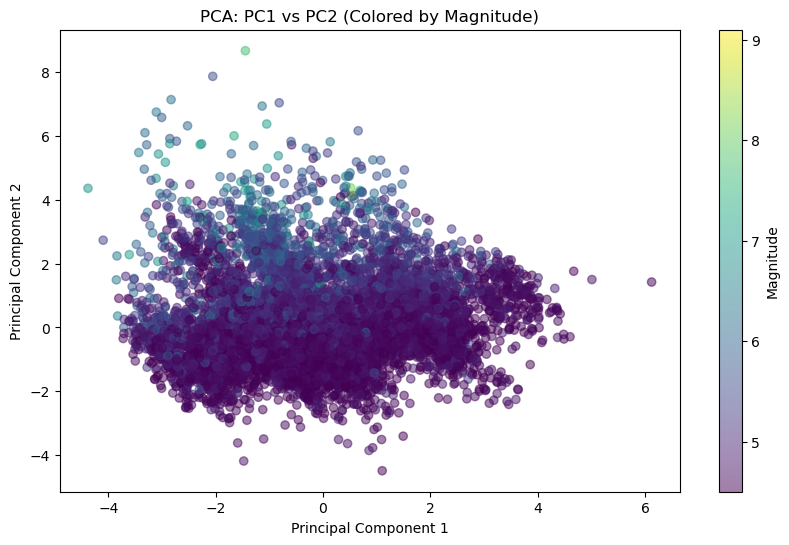

In [10]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Run the Multiple Linear Regression again using the PCA data
pca_lr_model = LinearRegression()
pca_lr_model.fit(X_train_pca, y_train)


y_pred_pca = pca_lr_model.predict(X_test_pca)
print(f"PCA Model R-squared: {r2_score(y_test, y_pred_pca)}")
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")

# 4. Visualization: PCA1 vs PCA2
plt.figure(figsize=(10, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='viridis', alpha=0.5)
plt.colorbar(label='Magnitude')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: PC1 vs PC2 (Colored by Magnitude)')
plt.show()

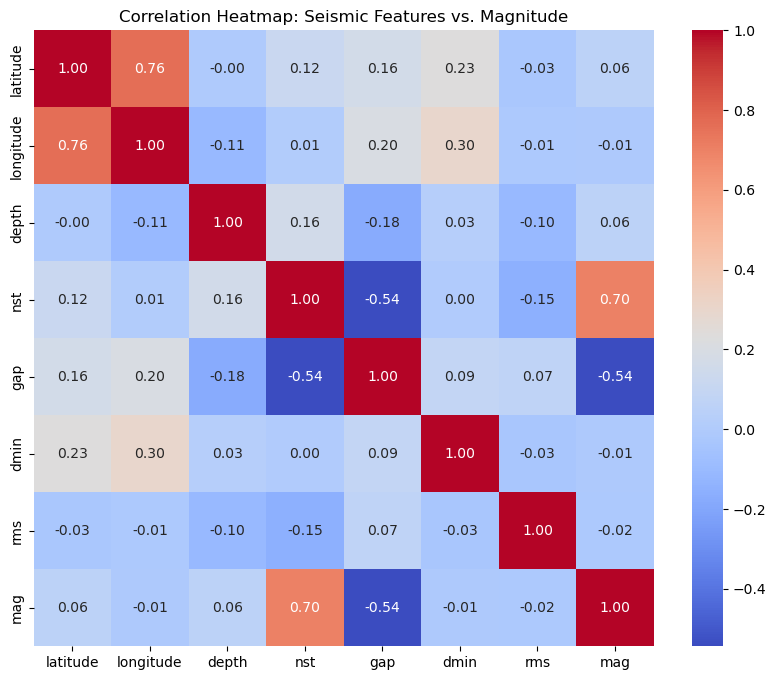

In [11]:
# EDA: Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[features + ['mag']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Seismic Features vs. Magnitude')
plt.show()